# The matrix class

In [2]:
import numpy as np

ndArray = np.arange(9).reshape(-1,3)
x = np.matrix(ndArray)
y = np.asmatrix(np.identity(3))
x

matrix([[0, 1, 2],
        [3, 4, 5],
        [6, 7, 8]])

In [3]:
y

matrix([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]])

In [4]:
x + y

matrix([[1., 1., 2.],
        [3., 5., 5.],
        [6., 7., 9.]])

In [5]:
x*y

matrix([[0., 1., 2.],
        [3., 4., 5.],
        [6., 7., 8.]])

In [6]:
x@y

matrix([[0., 1., 2.],
        [3., 4., 5.],
        [6., 7., 8.]])

In [7]:
np.dot(x,y)

matrix([[0., 1., 2.],
        [3., 4., 5.],
        [6., 7., 8.]])

In [8]:
A = np.asmatrix(
    [
     [3,1,4],
     [1,5,9],
     [2,6,5]   
    ]
)

b = np.asmatrix([1,2,3]).reshape(-1,1)

x = np.linalg.solve(A,b)

x

matrix([[ 0.26666667],
        [ 0.46666667],
        [-0.06666667]])

In [9]:
np.allclose(A@x, b)

True

# Linear algebra in Numpy

In [10]:
x = np.array([[1,2],[3,4]])
y = np.array([[10,20],[30,40]])
np.dot(x,y)

array([[ 70, 100],
       [150, 220]])

In [11]:
x@y

array([[ 70, 100],
       [150, 220]])

# Decomposition

In [12]:
x = np.random.randint(0,10,9).reshape(3,3)
x

array([[1, 7, 3],
       [6, 8, 9],
       [6, 8, 8]], dtype=int32)

In [13]:
w, v = np.linalg.eig(x)

In [14]:
w

array([19.72380529, -1.72380529, -1.        ])

In [15]:
v

array([[-3.56254015e-01, -8.95355902e-01, -8.32050294e-01],
       [-6.76841105e-01,  1.72415436e-01, -2.56023578e-16],
       [-6.44181027e-01,  4.10622365e-01,  5.54700196e-01]])

# Application

In [16]:
groups = [7, 24, 21, 19, 17, 12]
age = np.concatenate([np.random.randint((ind+1)*10, (ind+2)*10, size=group) for ind, group in enumerate(groups)])
age

array([12, 16, 14, 14, 18, 13, 11, 29, 23, 22, 29, 23, 28, 28, 20, 20, 22,
       21, 26, 23, 26, 26, 22, 27, 21, 21, 29, 25, 28, 29, 26, 38, 35, 32,
       35, 38, 36, 35, 33, 30, 36, 37, 30, 32, 30, 31, 33, 35, 33, 36, 39,
       35, 46, 46, 42, 42, 41, 47, 47, 40, 42, 45, 46, 45, 48, 47, 48, 42,
       49, 42, 45, 58, 56, 54, 57, 54, 51, 57, 58, 53, 50, 57, 51, 50, 57,
       57, 51, 53, 69, 63, 65, 62, 67, 61, 60, 69, 63, 67, 67, 60],
      dtype=int32)

In [17]:

scores = [5.5,5.7,5.4,4.9,4.6,4.4]
sim_scores = np.concatenate([0.01*np.random.rand(group)+ scores[ind] for ind, group in enumerate(groups)])
sim_scores

array([5.50798985, 5.50415272, 5.50414204, 5.50287025, 5.50502988,
       5.5004236 , 5.50117437, 5.70239853, 5.70059576, 5.70197294,
       5.70883993, 5.70606013, 5.7002611 , 5.70558064, 5.70414359,
       5.70446732, 5.7051559 , 5.70890556, 5.70446009, 5.70961831,
       5.70298042, 5.708033  , 5.70174062, 5.70143863, 5.70583202,
       5.70884208, 5.70602206, 5.7002047 , 5.70212941, 5.70342652,
       5.70005406, 5.40311002, 5.40433173, 5.40795172, 5.40877208,
       5.40483016, 5.40856026, 5.40389459, 5.40902953, 5.406863  ,
       5.40152004, 5.40243656, 5.40859185, 5.40442253, 5.40867808,
       5.40575872, 5.40110691, 5.40411581, 5.40250498, 5.40658762,
       5.40872438, 5.40807094, 4.90451141, 4.90158031, 4.90372595,
       4.90910899, 4.90930402, 4.90587134, 4.90280636, 4.90384198,
       4.90954532, 4.90966399, 4.9094048 , 4.90866517, 4.9092696 ,
       4.90084032, 4.90671704, 4.90845205, 4.90225314, 4.9070577 ,
       4.90239794, 4.60675778, 4.60455957, 4.60006594, 4.60581

In [18]:
AGE = np.vstack([age, np.ones(len(age))]).T
m, c = np.linalg.lstsq(AGE, sim_scores, rcond=None)[0]
m, c

(np.float64(-0.029354981802648283), np.float64(6.294982153735657))

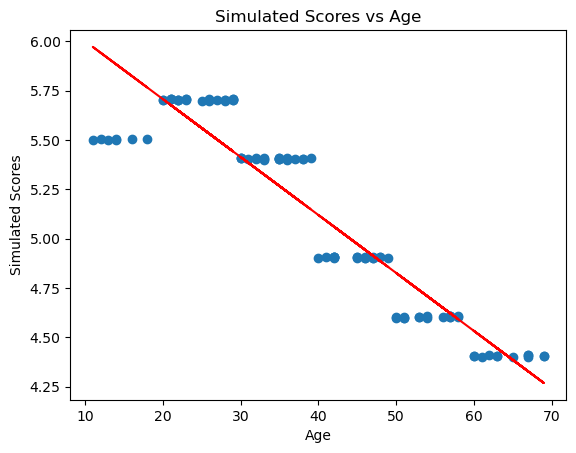

In [22]:
import matplotlib.pyplot as plt
plt.scatter(age, sim_scores)
plt.plot(age, m*age+c, color='red')
plt.xlabel('Age')
plt.ylabel('Simulated Scores')
plt.title('Simulated Scores vs Age')
plt.show()